
---

# 🌳 ***`Decision Trees in Machine Learning for Data Science`***  

---

## ✅ **What is a Decision Tree?**  
📌 **Decision Trees** are supervised learning algorithms used for both **classification** and **regression** tasks.  
📌 They mimic human decision-making by splitting data into branches based on feature values, forming a tree-like structure.  

✅ Easy to understand and visualize.  
✅ Suitable for both **linear** and **non-linear** relationships.  
✅ Require minimal data preprocessing (e.g., no need for scaling or normalization).  

---

## 📊 **1. Geometric Intuition Behind Decision Trees**  

A **Decision Tree** partitions the feature space into distinct **rectangular regions**.  
- Each split creates **decision boundaries** that divide the data into smaller regions.  
- The model predicts the **most common label** (classification) or the **average value** (regression) within each region.  

### 🔹 **Geometric Example**
Suppose we have a dataset with two features:  
- **X-axis → Feature 1**  
- **Y-axis → Feature 2**  

A Decision Tree will recursively split the data into **rectangular regions** to classify or predict outcomes.  

---

## 📉 **2. Decision Tree Components**  

### 🔹 **Root Node**  
- The **starting point** of the tree.  
- Contains the **entire dataset**.  

### 🔹 **Internal Nodes (Decision Nodes)**  
- Each node represents a **feature condition** that splits the data.  

### 🔹 **Leaf Nodes (Terminal Nodes)**  
- Represent the **final prediction** (class label or regression value).  

![dt](https://images.datacamp.com/image/upload/v1677504957/decision_tree_for_heart_attack_prevention_2140bd762d.png)

## 🔎 **3. How Does a Decision Tree Split Data?**  

📌 The algorithm chooses the **best split** at each step by measuring how well a feature separates the data. The criteria for this split are based on:  
1️⃣ **Entropy**  
2️⃣ **Gini Impurity**  
3️⃣ **Information Gain**  

---

## 📏 **4. Entropy in Decision Trees**  

📌 **Entropy** measures the **impurity** (or randomness) of a dataset.  
- Lower entropy → **More pure** nodes.  
- Higher entropy → **More disorder** (less pure).  

### 🔹 **Entropy Formula:**

$
Entropy = - \sum_{i=1}^{c} p_i \log_2(p_i)
$

Where:  
- $ c $ = Number of classes.  
- $ p_i $ = Probability of class $ i $ in the dataset.  

### 🔹 **Entropy Values:**  
- **Entropy = 0** → Completely pure (all samples belong to one class).  
- **Entropy = 1** → Maximum impurity (50/50 split in binary classification).  

---

## 📈 **5. Gini Impurity in Decision Trees**  

📌 **Gini Impurity** measures the probability that a randomly chosen sample is incorrectly classified.  
- Lower Gini → **More pure** nodes.  
- Higher Gini → **More impurity**.  

### 🔹 **Gini Impurity Formula:**

$
Gini = 1 - \sum_{i=1}^{c} p_i^2
$

Where:  
- $ p_i $ = Probability of class $ i $ in the dataset.  

### 🔹 **Gini Values:**  
- **Gini = 0** → Completely pure (all samples belong to one class).  
- **Gini = 0.5** → Maximum impurity in a binary split.  

---

## 🔍 **6. Information Gain in Decision Trees**  

📌 **Information Gain** measures the **reduction in impurity** after a split. The higher the Information Gain, the better the feature for splitting data.  

### 🔹 **Information Gain Formula:**

$
Information\ Gain = Entropy(parent) - \sum \frac{N_{child}}{N_{parent}} \times Entropy(child)
$

Where:  
- **Entropy(parent)** = Entropy before the split.  
- **Entropy(child)** = Weighted average entropy after the split.  

✅ **The feature with the highest Information Gain is selected for the split.**  

---

## 🏹 **7. Implementing Decision Trees in Python**  

### 📁 **Dataset: Iris Flower Classification**  

Accuracy: 0.9777777777777777

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



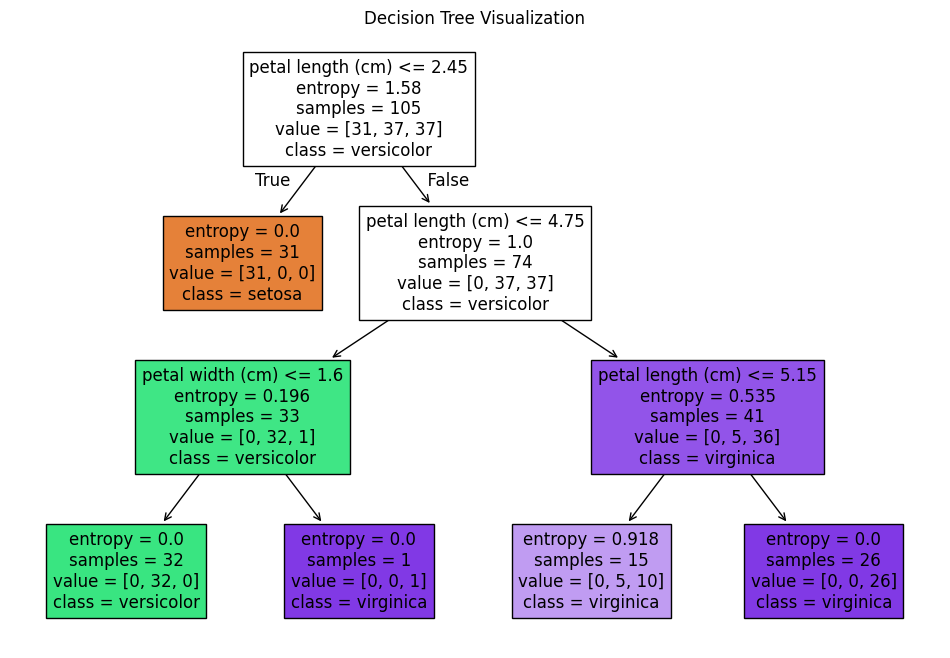

In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

# Load Dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Decision Tree Model
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualize Decision Tree
plt.figure(figsize=(12, 8))
tree.plot_tree(dt_model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.title("Decision Tree Visualization")
plt.show()

---

## 📊 **8. Understanding the Tree Visualization**  

🟩 **Leaf Nodes** → Final prediction labels.  
🔹 **Internal Nodes** → Decision conditions (e.g., `petal width <= 1.75`).  
📋 **Gini/Entropy Values** → Node purity.  
📊 **Samples** → Number of data points in each node.  
📊 **Class Distribution** → Breakdown of class labels in each node.  

---

## ⚙️ **9. Hyperparameters in Decision Trees**  

✅ **`criterion`** → `"entropy"` or `"gini"` (Controls impurity calculation).  
✅ **`max_depth`** → Limits the tree depth to prevent overfitting.  
✅ **`min_samples_split`** → Minimum samples required to split a node.  
✅ **`min_samples_leaf`** → Minimum samples required in a leaf node.  
✅ **`max_features`** → Limits the number of features considered for splitting.  

### 🔹 **Hyperparameter Tuning Example**

In [2]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Accuracy: 0.9428571428571428



---

## 🔥 **10. Decision Tree Strengths & Weaknesses**  

### ✅ **Strengths**  
✔️ Easy to understand and visualize.  
✔️ Requires little data preparation (no need for scaling/normalization).  
✔️ Suitable for both **classification** and **regression** tasks.  
✔️ Handles **non-linear relationships** effectively.  

### ❌ **Weaknesses**  
❌ **Prone to overfitting** if the tree is too deep.  
❌ **Unstable** → Small data changes may lead to a different tree structure.  
❌ Less effective on **high-dimensional data** (consider Random Forest or Gradient Boosting).  

---

## 🌍 **11. Real-World Applications of Decision Trees**  

✅ **Healthcare** → Diagnosing diseases based on symptoms.  
✅ **Finance** → Predicting loan default risk.  
✅ **Marketing** → Customer segmentation for targeted ads.  
✅ **Fraud Detection** → Identifying suspicious transactions.  
✅ **Churn Prediction** → Predicting customer retention.  

---

## 🏆 **12. Key Takeaways**  

✔️ **Decision Trees are powerful, interpretable models** that excel in structured data problems.  
✔️ They use **Entropy**, **Gini Impurity**, and **Information Gain** to determine the best splits.  
✔️ Use **`max_depth`**, **`min_samples_split`**, and **`min_samples_leaf`** to prevent overfitting.  
✔️ Combine multiple trees using **Random Forest** or **Gradient Boosting** for better performance.  

💡 **Pro Tip:** Decision Trees are often improved using **ensemble techniques** like **Random Forest**, **XGBoost**, or **LightGBM** for better accuracy and robustness.

---